In [4]:
!pip install pythainlp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.3/19.3 MB 61.0 MB/s eta 0:00:00


In [1]:
import pandas as pd
df=pd.read_csv('/content/drive/MyDrive/DataScience/Datasets/pizza-UTF8-traindataset-3.csv')
df=df.rename(columns={'class':'class_label','message':'text'})
df

,class_label,text
0,0,วันนี้สั่งมา...\rส่งก็ช้า เปิดมาก็ไม่มีซอส ไม่...
1,0,สปาเกตตี้ขี้เมา เค็มมากกกกกกกกกก\rกินคำเดียวพุ...
2,0,ตอนนี้กินอยู่ที่เซ็นทรัลพระราม2 \rเรื่องอาหาร ...
3,0,วันนี้สั่งมากินที่บ้าน รสชาติของสปาเกตตี้ ซีฟู...
4,0,วันที่29 ณ.สาขาริเวอร์ไซค์ตรงข้ามสน.บุคคโล ผมจ...
...,...,...
73,1,บริการดีมากค่ะ พอดีสั่งแล้วฝนพึ่งตก manager เด...
74,1,ชอบแป้งบางกรอบที่ซูดเลย เครื่องเนื้อแน่น ซอลอร...
75,1,สั่งออนไลน์ ง่ายสะดวก ส่งตรงเวลา พิซซ่าแป้งบาง...
76,1,โคตรอร่อย จัดให้เป็นที่สุดแห่งพิซซ่ายี่ห้อตลาด...


In [5]:
import re
import string
from pythainlp.corpus.common import thai_stopwords
from pythainlp.tokenize import word_tokenize

thai_stopwords = list(thai_stopwords())
thai_stopwords

def perform_removal(word):
    #กำจัดช่องว่างก่อน/หลังคำ
    word = word.strip()

    #เปลี่ยนภาษาอังกฤษเป็นตัวอักษรตัวเล็ก
    word = word.lower()

    #กำจัดเครื่องหมายวรรคตอน
    word = word.translate(str.maketrans('','', string.punctuation))

    #กำจัด stop words และตัวเลขโดดๆ
    if(word.isdigit() ):
        return ""
    else:
        return word

def clean_text(text):
  text = "".join(u for u in text if u not in ("?", ".", ";", ":", "!", '"', "ๆ", "ฯ","'"))
  tokens=word_tokenize(text, engine="oskut", keep_whitespace=False)

  tokens = [word for word in tokens if word.lower not in thai_stopwords]

  tokens = [word for word in tokens if len(word)>1]

  tokens = [perform_removal(word) for word in tokens]


  text = ' '.join(tokens)
  return text

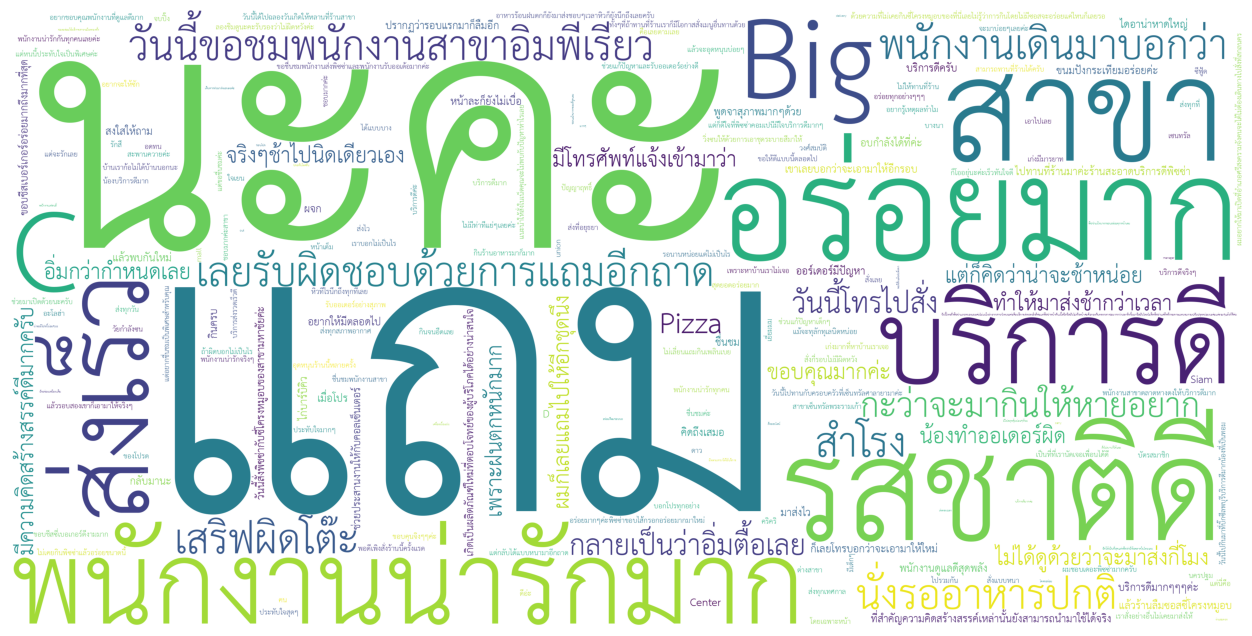

In [8]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

df_pos = df[df['class_label'] == 1]
pos_word_all = " ".join(text for text in df_pos['text'])
reg = r"[ก-๙a-zA-Z']+"
fp = '/content/drive/MyDrive/DataScience/Datasets/THSarabunNew.ttf'
wordcloud = WordCloud(stopwords=thai_stopwords, background_color = 'white', max_words=2000, height = 2000, width=4000, font_path=fp, regexp=reg).generate(pos_word_all)
plt.figure(figsize = (16,8))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

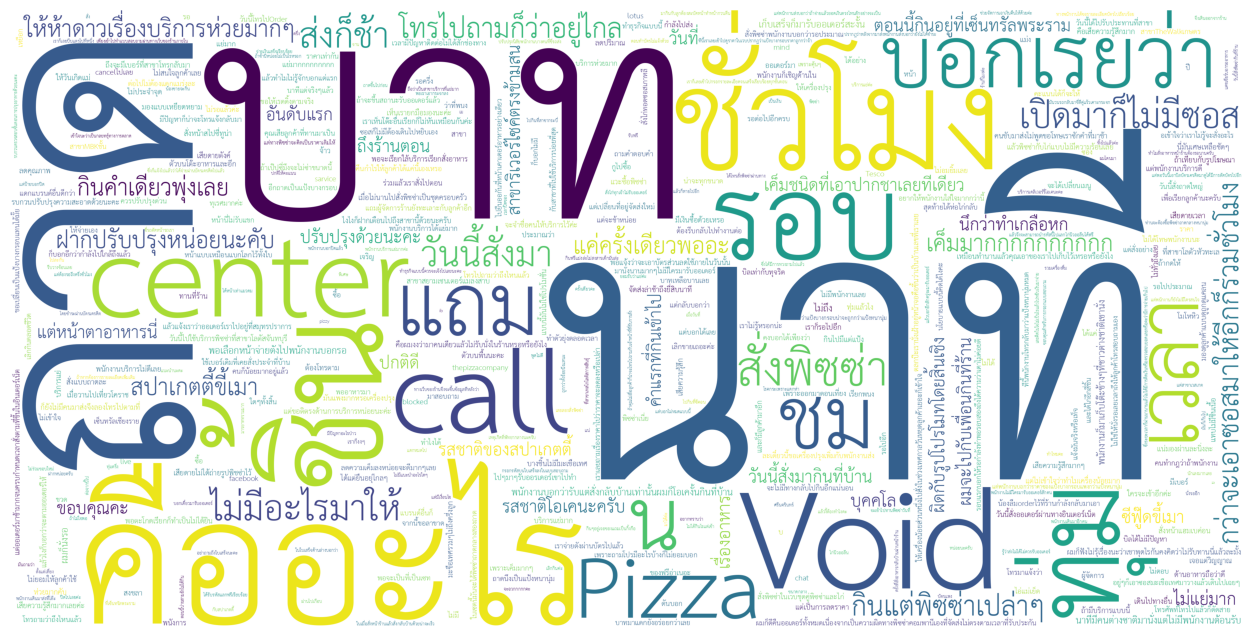

In [9]:
df_neg = df[df['class_label'] == 0]
neg_word_all = " ".join(text for text in df_neg['text'])
wordcloud = WordCloud(stopwords=thai_stopwords, background_color = 'white', max_words=2000, height = 2000, width=4000, font_path=fp, regexp=reg).generate(neg_word_all)
plt.figure(figsize = (16,8))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [34]:
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df, test_size=0.20, stratify=df['class_label'])

from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer

def identity_fun(text):
    return text.split()


# CountVectorizer
vec = CountVectorizer(
    analyzer = 'word', #this is default
    tokenizer=identity_fun, #does no extra tokenizing
    ngram_range=(1,3),
    max_features=100
)


'''
#TFIDF
vec = TfidfVectorizer(
    analyzer = 'word', #this is default
    tokenizer=identity_fun, #does no extra tokenizing
    ngram_range=(1,3),
    max_features=300
)
'''


vec.fit(df_train['text'])
vec.vocabulary_

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


{'10': np.int64(36),
 'ไม่เคยกินพิซซ่าแล้วอร่อยขนาดนี้': np.int64(87),
 '10 10': np.int64(37),
 '10 ไม่เคยกินพิซซ่าแล้วอร่อยขนาดนี้': np.int64(42),
 'ไม่เคยกินพิซซ่าแล้วอร่อยขนาดนี้ จะมาบ่อยๆเลยค่ะ': np.int64(88),
 '10 10 10': np.int64(38),
 '10 10 ไม่เคยกินพิซซ่าแล้วอร่อยขนาดนี้': np.int64(39),
 '10 ไม่เคยกินพิซซ่าแล้วอร่อยขนาดนี้ จะมาบ่อยๆเลยค่ะ': np.int64(43),
 'ไม่เคยกินพิซซ่าแล้วอร่อยขนาดนี้ จะมาบ่อยๆเลยค่ะ รักสึ': np.int64(89),
 'สั่งพิซซ่า': np.int64(75),
 '1': np.int64(23),
 'ถาด': np.int64(69),
 'คืออะไร': np.int64(68),
 'สั่งพิซซ่า 1': np.int64(76),
 '1 ถาด': np.int64(29),
 '1 จาน': np.int64(24),
 'สั่งพิซซ่า 1 ถาด': np.int64(77),
 '1 ถาด กับสปาเกตตี้': np.int64(30),
 '1 จาน ที่สาขาเทสโกโลตัสกาฬสินธุ์': np.int64(25),
 'center': np.int64(65),
 'pizza': np.int64(66),
 '1 ตัวบนโต๊ะอาหารและอีก': np.int64(27),
 '1 ตัวบนพื้นนะคะ': np.int64(26),
 '1 ตัวบนโต๊ะอาหารและอีก 1': np.int64(28),
 'void': np.int64(67),
 'ไม่ได้': np.int64(93),
 'ไม่ได้ ไม่ได้โทษพนักงานนะ': np.int64(94),
 'ไม

In [35]:
vec.get_feature_names_out()

array(['"น้องลืมorderไว้ที่ร้านกำลังกลับมาเอา"',
       '"น้องลืมorderไว้ที่ร้านกำลังกลับมาเอา" ....',
       '"น้องลืมorderไว้ที่ร้านกำลังกลับมาเอา" .... คงบอกได้เพียงว่า',
       '"ไม่รอแล้วค่ะ', '"ไม่รอแล้วค่ะ cancelไปเลย"',
       '"ไม่รอแล้วค่ะ cancelไปเลย" เราไม่รู้หรอกน่ะ', '#1112',
       '#1112 #เลิกกินตลอดชีวิต', '#1112 #เลิกกินตลอดชีวิต #โมโหหิว',
       '#1112 เวลา', '#1112 เวลา 20:34', '#thepizzacompany',
       '#thepizzacompany #1112',
       '#thepizzacompany #1112 #เลิกกินตลอดชีวิต', '#สาขาthewalkเกษตร',
       '....',
       '0 เลยคิดในใจไม่เป็นไรแล้วไปหยิบเงินมาจ่าย แต่พอวันนี้เอาบิลบัตรเครดิตมาดูได้มีการตัดบัตรไปอีก',
       '02.04.60', '02.04.60 ได้โทรสั่งพิซซ่าผ่านทาง',
       '02.04.60 ได้โทรสั่งพิซซ่าผ่านทาง 1112', '092-2810673',
       '092-2810673 โทรมาแจ้งว่า', '092-2810673 โทรมาแจ้งว่า กำลังไปส่ง',
       '1', '1 จาน', '1 จาน ที่สาขาเทสโกโลตัสกาฬสินธุ์',
       '1 ตัวบนพื้นนะคะ', '1 ตัวบนโต๊ะอาหารและอีก',
       '1 ตัวบนโต๊ะอาหารและอีก 1', '1 ถาด', '1 ถาด กั

In [36]:
import numpy as np

#สุ่มช่วงของ 5 เอกสารที่ติดกันมาทดลองใช้งาน
count_vector= vec.transform(df_train['text'][:10])
count_array = np.array(count_vector.todense())

#แปลงเป็น DataFrame เพื่อง่ายแก่การอ่าน
df_x = pd.DataFrame(count_array,columns=vec.get_feature_names_out())
df_x

,"""น้องลืมorderไว้ที่ร้านกำลังกลับมาเอา""","""น้องลืมorderไว้ที่ร้านกำลังกลับมาเอา"" ....","""น้องลืมorderไว้ที่ร้านกำลังกลับมาเอา"" .... คงบอกได้เพียงว่า","""ไม่รอแล้วค่ะ","""ไม่รอแล้วค่ะ cancelไปเลย""","""ไม่รอแล้วค่ะ cancelไปเลย"" เราไม่รู้หรอกน่ะ",#1112,#1112 #เลิกกินตลอดชีวิต,#1112 #เลิกกินตลอดชีวิต #โมโหหิว,#1112 เวลา,...,ไม่เลี่ยนแถมกินเพลินเบย,ไม่ให้ทานที่ร้าน,ไม่ให้ทานที่ร้าน ทั้งๆที่ถ้าทานที่ร้านเราก็มีโอกาสสั่งเมนูอื่นทานด้วย,ไม่ได้,ไม่ได้ ไม่ได้โทษพนักงานนะ,ไม่ได้ ไม่ได้โทษพนักงานนะ คนทำกฎว่าถ้าพนักงาน,ไม่ได้กินไรแต่เช้า,ไม่ได้กินไรแต่เช้า กินฟรีแม่งล่ะไม่สงสารเด็กมันล่ะ,ไม่ได้กินไรแต่เช้า กินฟรีแม่งล่ะไม่สงสารเด็กมันล่ะ รู้ว่าส่งไม่ได้ไม่ควรรับออเดอร์,ไม่ได้ดูด้วยว่าจะมาส่งกี่โมง
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [37]:
X_train = vec.transform(df_train.text)
X_test = vec.transform(df_test.text)

y_train = df_train['class_label']
y_test = df_test['class_label']

In [61]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, classification_report

dt=DecisionTreeClassifier()
dt.fit(X_train, y_train)

preds = dt.predict(X_test)
print(classification_report(y_test, preds))

ValueError: could not convert string to float: 'ชื่นชมพนักงานสาขา Big C สะพานควายค่ะ สั่งแบบหนา ได้แบบบาง เราบอกไม่เป็นไร แต่กลับได้แบบหนามาอีกถาด กินจนอืดเลย พนักงานน่ารักทุกคน บริการดีมาก กินร้านอาหารมาก็มาก ถ้าผิดบอกไม่เป็นไร คือเลยตามเลย แต่นี่คือ ดีอ่ะ ประทับใจมากๆ'

In [60]:
from sklearn.tree import export_graphviz
import graphviz

# Export decision tree to graphviz format
dot_data = export_graphviz(dt, out_file=None,
                           feature_names = vec.get_feature_names_out(),
                           class_names=['Neg','Pos'],
                           filled=True, rounded=True,
                           special_characters=True)

# Visualize decision tree using graphviz
graph = graphviz.Source(dot_data)
graph.format = 'png'
graph.render("Pizza_decision_tree")
graph # Display decision tree

NotFittedError: This DecisionTreeClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [55]:
# 1. Import library ที่จำเป็น
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# 2. โหลดข้อมูล (เช่น pizza_reviews.csv)
df = pd.read_csv('/content/drive/MyDrive/DataScience/Datasets/pizza-UTF8-traindataset-3.csv')  # ต้องมีคอลัมน์ text, label

# 3. แบ่ง Train/Test
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['class'], test_size=0.25, random_state=42)

# 4. ทดลองหลายค่า max_features
results = []
for k in [100, 500, 1000, 2000, 5000]:
    vec = CountVectorizer(max_features=k)
    X_train_vec = vec.fit_transform(X_train)
    X_test_vec = vec.transform(X_test)

    model = MultinomialNB()
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)

    acc = accuracy_score(y_test, y_pred)
    results.append((k, acc))
    print(f"max_features={k}, Accuracy={acc:.4f}")

# 5. แสดงค่า max_features ที่ดีที่สุด
best = max(results, key=lambda x: x[1])
print("\n✅ Best max_features:", best[0], "with Accuracy =", round(best[1], 4))


max_features=100, Accuracy=0.8000
max_features=500, Accuracy=0.7000
max_features=1000, Accuracy=0.7000
max_features=2000, Accuracy=0.6500
max_features=5000, Accuracy=0.6500

✅ Best max_features: 100 with Accuracy = 0.8


📋 คอลัมน์ทั้งหมด: ['class', 'text']

ตัวอย่างข้อมูล:
   class                                               text
0      0  วันนี้สั่งมา...\rส่งก็ช้า เปิดมาก็ไม่มีซอส ไม่...
1      0  สปาเกตตี้ขี้เมา เค็มมากกกกกกกกกก\rกินคำเดียวพุ...
2      0  ตอนนี้กินอยู่ที่เซ็นทรัลพระราม2 \rเรื่องอาหาร ...
3      0  วันนี้สั่งมากินที่บ้าน รสชาติของสปาเกตตี้ ซีฟู...
4      0  วันที่29 ณ.สาขาริเวอร์ไซค์ตรงข้ามสน.บุคคโล ผมจ...
max_features=100, Accuracy=0.7000
max_features=500, Accuracy=0.7000
max_features=1000, Accuracy=0.6000
max_features=2000, Accuracy=0.6500
max_features=5000, Accuracy=0.6500

✅ Best max_features: 100 with Accuracy = 0.7


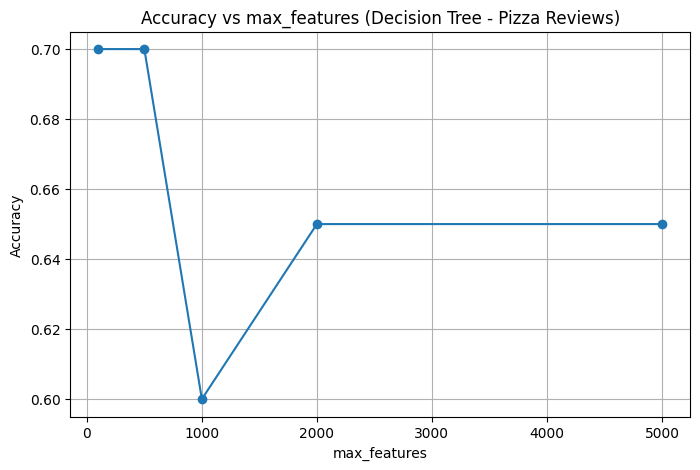

In [56]:
# 1. Import library ที่จำเป็น
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# 2. โหลดข้อมูล (ต้องมีคอลัมน์ text, class)
df = pd.read_csv('/content/drive/MyDrive/DataScience/Datasets/pizza-UTF8-traindataset-3.csv')

print("📋 คอลัมน์ทั้งหมด:", df.columns.tolist())
print("\nตัวอย่างข้อมูล:")
print(df.head())

# 3. แบ่ง Train/Test
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['class'], test_size=0.25, random_state=42)

# 4. ทดลองหลายค่า max_features
results = []
for k in [100, 500, 1000, 2000, 5000]:
    vec = CountVectorizer(max_features=k)
    X_train_vec = vec.fit_transform(X_train)
    X_test_vec = vec.transform(X_test)

    # ✅ ใช้ Decision Tree แทน Naive Bayes
    model = DecisionTreeClassifier(random_state=42)
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)

    acc = accuracy_score(y_test, y_pred)
    results.append((k, acc))
    print(f"max_features={k}, Accuracy={acc:.4f}")

# 5. หาค่า max_features ที่ให้ Accuracy สูงสุด
best = max(results, key=lambda x: x[1])
print("\n✅ Best max_features:", best[0], "with Accuracy =", round(best[1], 4))

# 6. แสดงกราฟผลลัพธ์
k_values = [r[0] for r in results]
acc_values = [r[1] for r in results]

plt.figure(figsize=(8,5))
plt.plot(k_values, acc_values, marker='o')
plt.title("Accuracy vs max_features (Decision Tree - Pizza Reviews)")
plt.xlabel("max_features")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


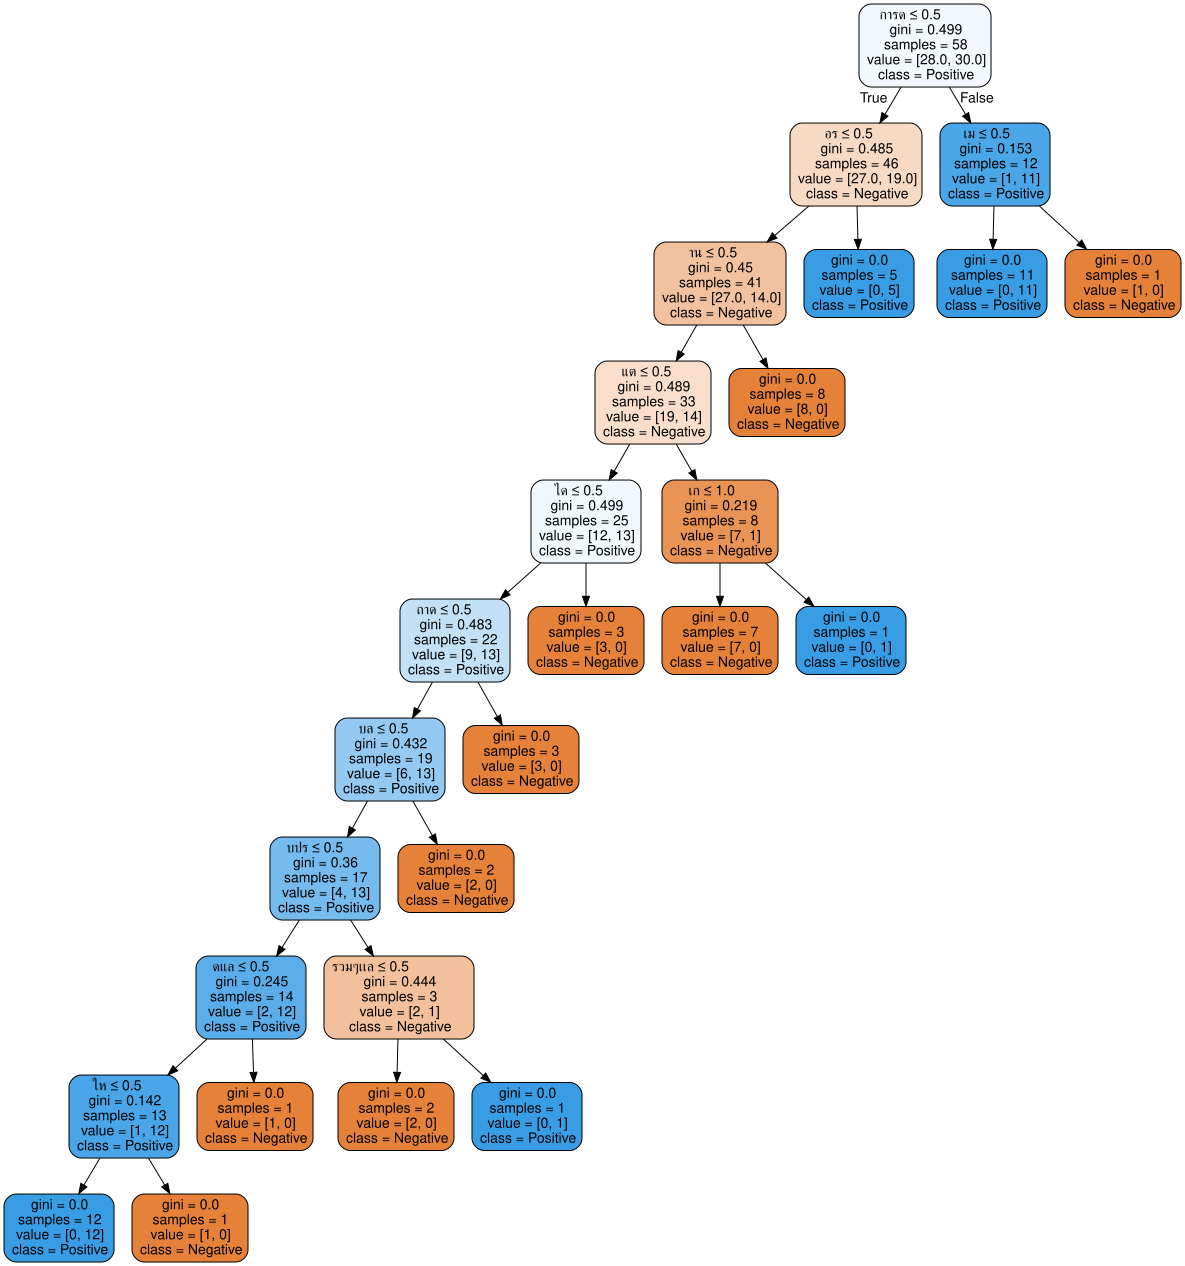

In [57]:
from sklearn.tree import export_graphviz
import graphviz

# Export Decision Tree เป็น .pdf หรือ .png
dot_data = export_graphviz(model, out_file=None,
                           feature_names=vec.get_feature_names_out(),
                           class_names=['Negative', 'Positive'],
                           filled=True, rounded=True,
                           special_characters=True)

graph = graphviz.Source(dot_data)
graph.format = 'png'              # หรือ 'pdf'
graph.render("Pizza_decision_tree")
graph
